# Process DWD Data by Geographical Location

This notebook processes all station directories and creates separate `produkt_tu_stunde` files for each unique latitude/longitude pair.

**Process:**
1. For each station directory, read `Metadaten_Geographie` and `produkt_tu_stunde` files
2. Group geography entries by unique (latitude, longitude) pairs
3. For each unique lat/lon pair, filter temperature data by date ranges
4. Add `latitude` and `longitude` columns to the data
5. Create separate CSV files for each location (including empty files when no data exists)
6. Save files in the same directory as input files


In [ ]:
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import traceback


In [ ]:
# Configuration
BASE_DIR = Path("/mnt/d/heatpump_data/climate_data/dwd_historical_hourly_temperature_extracted_csv")

print(f"Base directory: {BASE_DIR}")
print(f"Directory exists: {BASE_DIR.exists()}")


Base directory: /mnt/d/heatpump_data/climate_data/dwd_historical_hourly_temperature_extracted_csv
Directory exists: True


In [ ]:
def find_geography_and_produkt_files(station_dir):
    """
    Find Metadaten_Geographie and produkt_tu_stunde files in a station directory.
    
    Args:
        station_dir: Path to station directory
        
    Returns:
        Tuple of (geography_file_path, produkt_file_path) or (None, None) if not found
    """
    csv_files = list(station_dir.glob("*.csv"))
    
    geography_file = None
    produkt_file = None
    
    for f in csv_files:
        if "Metadaten_Geographie" in f.name:
            geography_file = f
        elif "produkt_tu_stunde" in f.name and "_lat_" not in f.name:
            # Only match original produkt files, not the ones we create
            produkt_file = f
    
    return geography_file, produkt_file


In [ ]:
def process_station_by_location(station_dir, verbose=False):
    """
    Process a single station: create separate produkt_tu_stunde files for each unique lat/lon pair.
    Creates files even when no data exists for a location (empty files with headers).
    
    Args:
        station_dir: Path to station directory containing CSV files
        verbose: If True, print detailed progress information
        
    Returns:
        Dictionary with processing results
    """
    # Find files
    geo_file, prod_file = find_geography_and_produkt_files(station_dir)
    
    if geo_file is None or prod_file is None:
        return {
            'status': 'skipped',
            'reason': 'Missing files',
            'geography_file': geo_file.name if geo_file else None,
            'produkt_file': prod_file.name if prod_file else None
        }
    
    try:
        # Read geography metadata
        geo_df = pd.read_csv(geo_file)
        
        # Read produkt temperature data
        prod_df = None
        if prod_file.exists():
            prod_df = pd.read_csv(prod_file)
            
            # Extract date from MESS_DATUM (first 8 characters: YYYYMMDD)
            prod_df['MESS_DATUM_date'] = pd.to_datetime(
                prod_df['MESS_DATUM'].astype(str).str[:8], 
                format='%Y%m%d',
                errors='coerce'
            )
        
        # Extract station ID
        station_id = geo_df['Stations_id'].iloc[0] if 'Stations_id' in geo_df.columns else None
        
        # Convert date columns to datetime for comparison
        geo_df['von_datum'] = pd.to_datetime(geo_df['von_datum'], format='%Y%m%d', errors='coerce')
        geo_df['bis_datum'] = pd.to_datetime(geo_df['bis_datum'], format='%Y%m%d', errors='coerce')
        
        # Group geography entries by unique (latitude, longitude) pairs
        location_groups = defaultdict(list)
        for idx, row in geo_df.iterrows():
            lat = row['Geogr.Breite']
            lon = row['Geogr.Laenge']
            location_groups[(lat, lon)].append({
                'von_datum': row['von_datum'],
                'bis_datum': row['bis_datum']
            })
        
        # Get column names from produkt file (for creating empty files)
        if prod_df is not None and len(prod_df) > 0:
            base_columns = list(prod_df.columns)
            # Remove temporary date column if it exists
            if 'MESS_DATUM_date' in base_columns:
                base_columns.remove('MESS_DATUM_date')
        else:
            # Default columns if no produkt file or empty
            base_columns = ['STATIONS_ID', 'MESS_DATUM', 'QN_9', 'TT_TU', 'RF_TU', 'eor']
        
        files_created = []
        files_with_data = 0
        files_empty = 0
        total_records = 0
        
        # Process each unique location
        for (lat, lon), date_ranges in location_groups.items():
            filtered_prod = None
            
            if prod_df is not None and len(prod_df) > 0:
                # Combine all date ranges for this location
                combined_mask = pd.Series([False] * len(prod_df))
                
                for date_range in date_ranges:
                    von_date = date_range['von_datum']
                    bis_date = date_range['bis_datum']
                    
                    # Skip if dates are invalid
                    if pd.isna(von_date) or pd.isna(bis_date):
                        continue
                    
                    # Filter produkt data for this date range
                    mask = (
                        (prod_df['MESS_DATUM_date'] >= von_date) & 
                        (prod_df['MESS_DATUM_date'] <= bis_date)
                    )
                    combined_mask = combined_mask | mask
                
                filtered_prod = prod_df[combined_mask].copy()
            
            # Create output dataframe
            if filtered_prod is not None and len(filtered_prod) > 0:
                # Remove the temporary date column if it exists
                if 'MESS_DATUM_date' in filtered_prod.columns:
                    filtered_prod = filtered_prod.drop(columns=['MESS_DATUM_date'])
                
                # Add latitude and longitude columns
                filtered_prod['latitude'] = lat
                filtered_prod['longitude'] = lon
                
                record_count = len(filtered_prod)
                total_records += record_count
                files_with_data += 1
            else:
                # Create empty dataframe with proper columns
                filtered_prod = pd.DataFrame(columns=base_columns + ['latitude', 'longitude'])
                record_count = 0
                files_empty += 1
            
            # Create output filename
            base_name = prod_file.stem
            # Format lat/lon to avoid issues with decimal points in filenames
            lat_str = str(lat).replace('.', '_')
            lon_str = str(lon).replace('.', '_')
            output_filename = f"{base_name}_lat_{lat_str}_lon_{lon_str}.csv"
            output_path = station_dir / output_filename
            
            # Save to CSV in the same directory
            filtered_prod.to_csv(output_path, index=False)
            files_created.append(output_filename)
            
            if verbose and record_count > 0:
                print(f"    Created: {output_filename} ({record_count} records)")
            elif verbose:
                print(f"    Created: {output_filename} (empty file - no data in date range)")
        
        return {
            'status': 'success',
            'station_id': station_id,
            'unique_locations': len(location_groups),
            'files_created': len(files_created),
            'files_with_data': files_with_data,
            'files_empty': files_empty,
            'total_records': total_records,
            'files': files_created
        }
        
    except Exception as e:
        return {
            'status': 'error',
            'error': str(e),
            'traceback': traceback.format_exc(),
            'station_dir': str(station_dir)
        }


In [ ]:
# Get all station directories
station_dirs = [d for d in BASE_DIR.iterdir() if d.is_dir()]
station_dirs.sort()

print(f"Found {len(station_dirs)} station directories to process")


Found 636 station directories to process


In [ ]:
# Process all stations
print("=" * 80)
print("Processing all stations...")
print("=" * 80)

results = []
success_count = 0
error_count = 0
skipped_count = 0

for station_dir in tqdm(station_dirs, desc="Processing stations", unit="station"):
    result = process_station_by_location(station_dir, verbose=False)
    result['station_dir'] = station_dir.name
    results.append(result)
    
    if result['status'] == 'success':
        success_count += 1
    elif result['status'] == 'error':
        error_count += 1
    elif result['status'] == 'skipped':
        skipped_count += 1

print("\n" + "=" * 80)
print("Processing complete!")
print("=" * 80)


Processing all stations...


Processing stations: 100%|██████████| 636/636 [10:59<00:00,  1.04s/station]


Processing complete!


In [ ]:
# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print(f"\nTotal stations processed: {len(results)}")
print(f"  Successfully processed: {success_count}")
print(f"  Errors: {error_count}")
print(f"  Skipped: {skipped_count}")

# Aggregate statistics from successful processing
successful_results = [r for r in results if r['status'] == 'success']

if successful_results:
    total_locations = sum(r['unique_locations'] for r in successful_results)
    total_files = sum(r['files_created'] for r in successful_results)
    total_files_with_data = sum(r.get('files_with_data', 0) for r in successful_results)
    total_files_empty = sum(r.get('files_empty', 0) for r in successful_results)
    total_records = sum(r.get('total_records', 0) for r in successful_results)
    
    print(f"\nFiles created:")
    print(f"  Total unique locations: {total_locations}")
    print(f"  Total files created: {total_files}")
    print(f"  Files with data: {total_files_with_data}")
    print(f"  Empty files: {total_files_empty}")
    print(f"  Total records: {total_records:,}")

# Show stations with errors
error_results = [r for r in results if r['status'] == 'error']
if error_results:
    print(f"\n{'=' * 80}")
    print(f"STATIONS WITH ERRORS ({len(error_results)}):")
    print("=" * 80)
    for r in error_results[:10]:  # Show first 10 errors
        print(f"\nStation: {r['station_dir']}")
        print(f"Error: {r['error']}")
    if len(error_results) > 10:
        print(f"\n... and {len(error_results) - 10} more errors")


In [ ]:
# Show stations that were skipped
skipped_results = [r for r in results if r['status'] == 'skipped']
if skipped_results:
    print(f"\n{'=' * 80}")
    print(f"SKIPPED STATIONS ({len(skipped_results)}):")
    print("=" * 80)
    for r in skipped_results[:10]:  # Show first 10
        print(f"  {r['station_dir']}: {r.get('reason', 'Unknown reason')}")
    if len(skipped_results) > 10:
        print(f"\n... and {len(skipped_results) - 10} more skipped")


In [ ]:
# Sample verification - check a few stations
print("\n" + "=" * 80)
print("SAMPLE VERIFICATION")
print("=" * 80)

sample_stations = [r for r in successful_results[:3]]

for result in sample_stations:
    station_dir = BASE_DIR / result['station_dir']
    output_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    print(f"\nStation: {result['station_dir']}")
    print(f"  Station ID: {result.get('station_id', 'N/A')}")
    print(f"  Unique locations: {result['unique_locations']}")
    print(f"  Files created: {result['files_created']}")
    print(f"  Files with data: {result.get('files_with_data', 0)}")
    print(f"  Empty files: {result.get('files_empty', 0)}")
    print(f"  Total records: {result.get('total_records', 0):,}")
    
    if output_files:
        print(f"  Sample files:")
        for f in sorted(output_files)[:3]:
            size_kb = f.stat().st_size / 1024
            df_check = pd.read_csv(f)
            record_count = len(df_check)
            print(f"    - {f.name} ({size_kb:.1f} KB, {record_count} records)")


# Exploring postal code data

## Getting Germany's map with postal code boundaries 

Source of postal code map: https://www.kaggle.com/datasets/jonaslneri/germany-plz

In [10]:
!uv pip install geopandas tabulate

Using Python 3.11.14 environment at: /home/abhishek/Documents/heatpump_ai_2/climate_data_prep/.venv
Resolved 13 packages in 200ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/34.43 KiB           
⠙ Preparing packages... (0/1)2m----------------- 16.00 KiB/34.43 KiB         
⠙ Preparing packages... (0/1)---------- 32.00 KiB/34.43 KiB         
⠙ Preparing packages... (0/1)---------- 34.43 KiB/34.43 KiB         
Prepared 1 package in 18ms                                                        
Installed 1 package in 4ms                                  
 + tabulate==0.9.0


In [16]:
!uv pip install matplotlib

Using Python 3.11.14 environment at: /home/abhishek/Documents/heatpump_ai_2/climate_data_prep/.venv
Resolved 11 packages in 270ms                                        
⠙ Preparing packages... (0/6)                                                   
⠙ Preparing packages... (0/6)-------------------     0 B/4.80 MiB            
⠙ Preparing packages... (0/6)------------------- 16.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 32.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 48.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.80 MiB          
contourpy            ------------------------------     0 B/346.91 KiB
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.80 MiB          
contourpy            ------------------------------     0 B/346.91 KiB
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.

In [3]:
import geopandas as gpd
from tabulate import tabulate

In [4]:


file_name = "plz-5stellig.shp"
path = f"/mnt/d/heatpump_data/postal_code_data/postal_code_map/{file_name}"
plz = gpd.read_file(path)  # adjust filename if needed

In [5]:
print()
print(tabulate(plz.head(), headers="keys", tablefmt="grid", showindex=False))


+-------+--------------------------------+-------------+-----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
print(plz.crs)
print(plz.columns)

EPSG:4326
Index(['plz', 'note', 'einwohner', 'qkm', 'geometry'], dtype='object')


In [7]:
plz = plz.to_crs("EPSG:4326")

In [8]:
print(tabulate(plz.head(), headers="keys", tablefmt="grid", showindex=False))

+-------+--------------------------------+-------------+-----------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [12]:
# plz.describe()
plz["qkm"].describe()

count    8170.000000
mean       43.730761
std        52.647218
min         0.001829
25%        12.745523
50%        27.278689
75%        56.223991
max       891.886712
Name: qkm, dtype: float64

<Axes: >

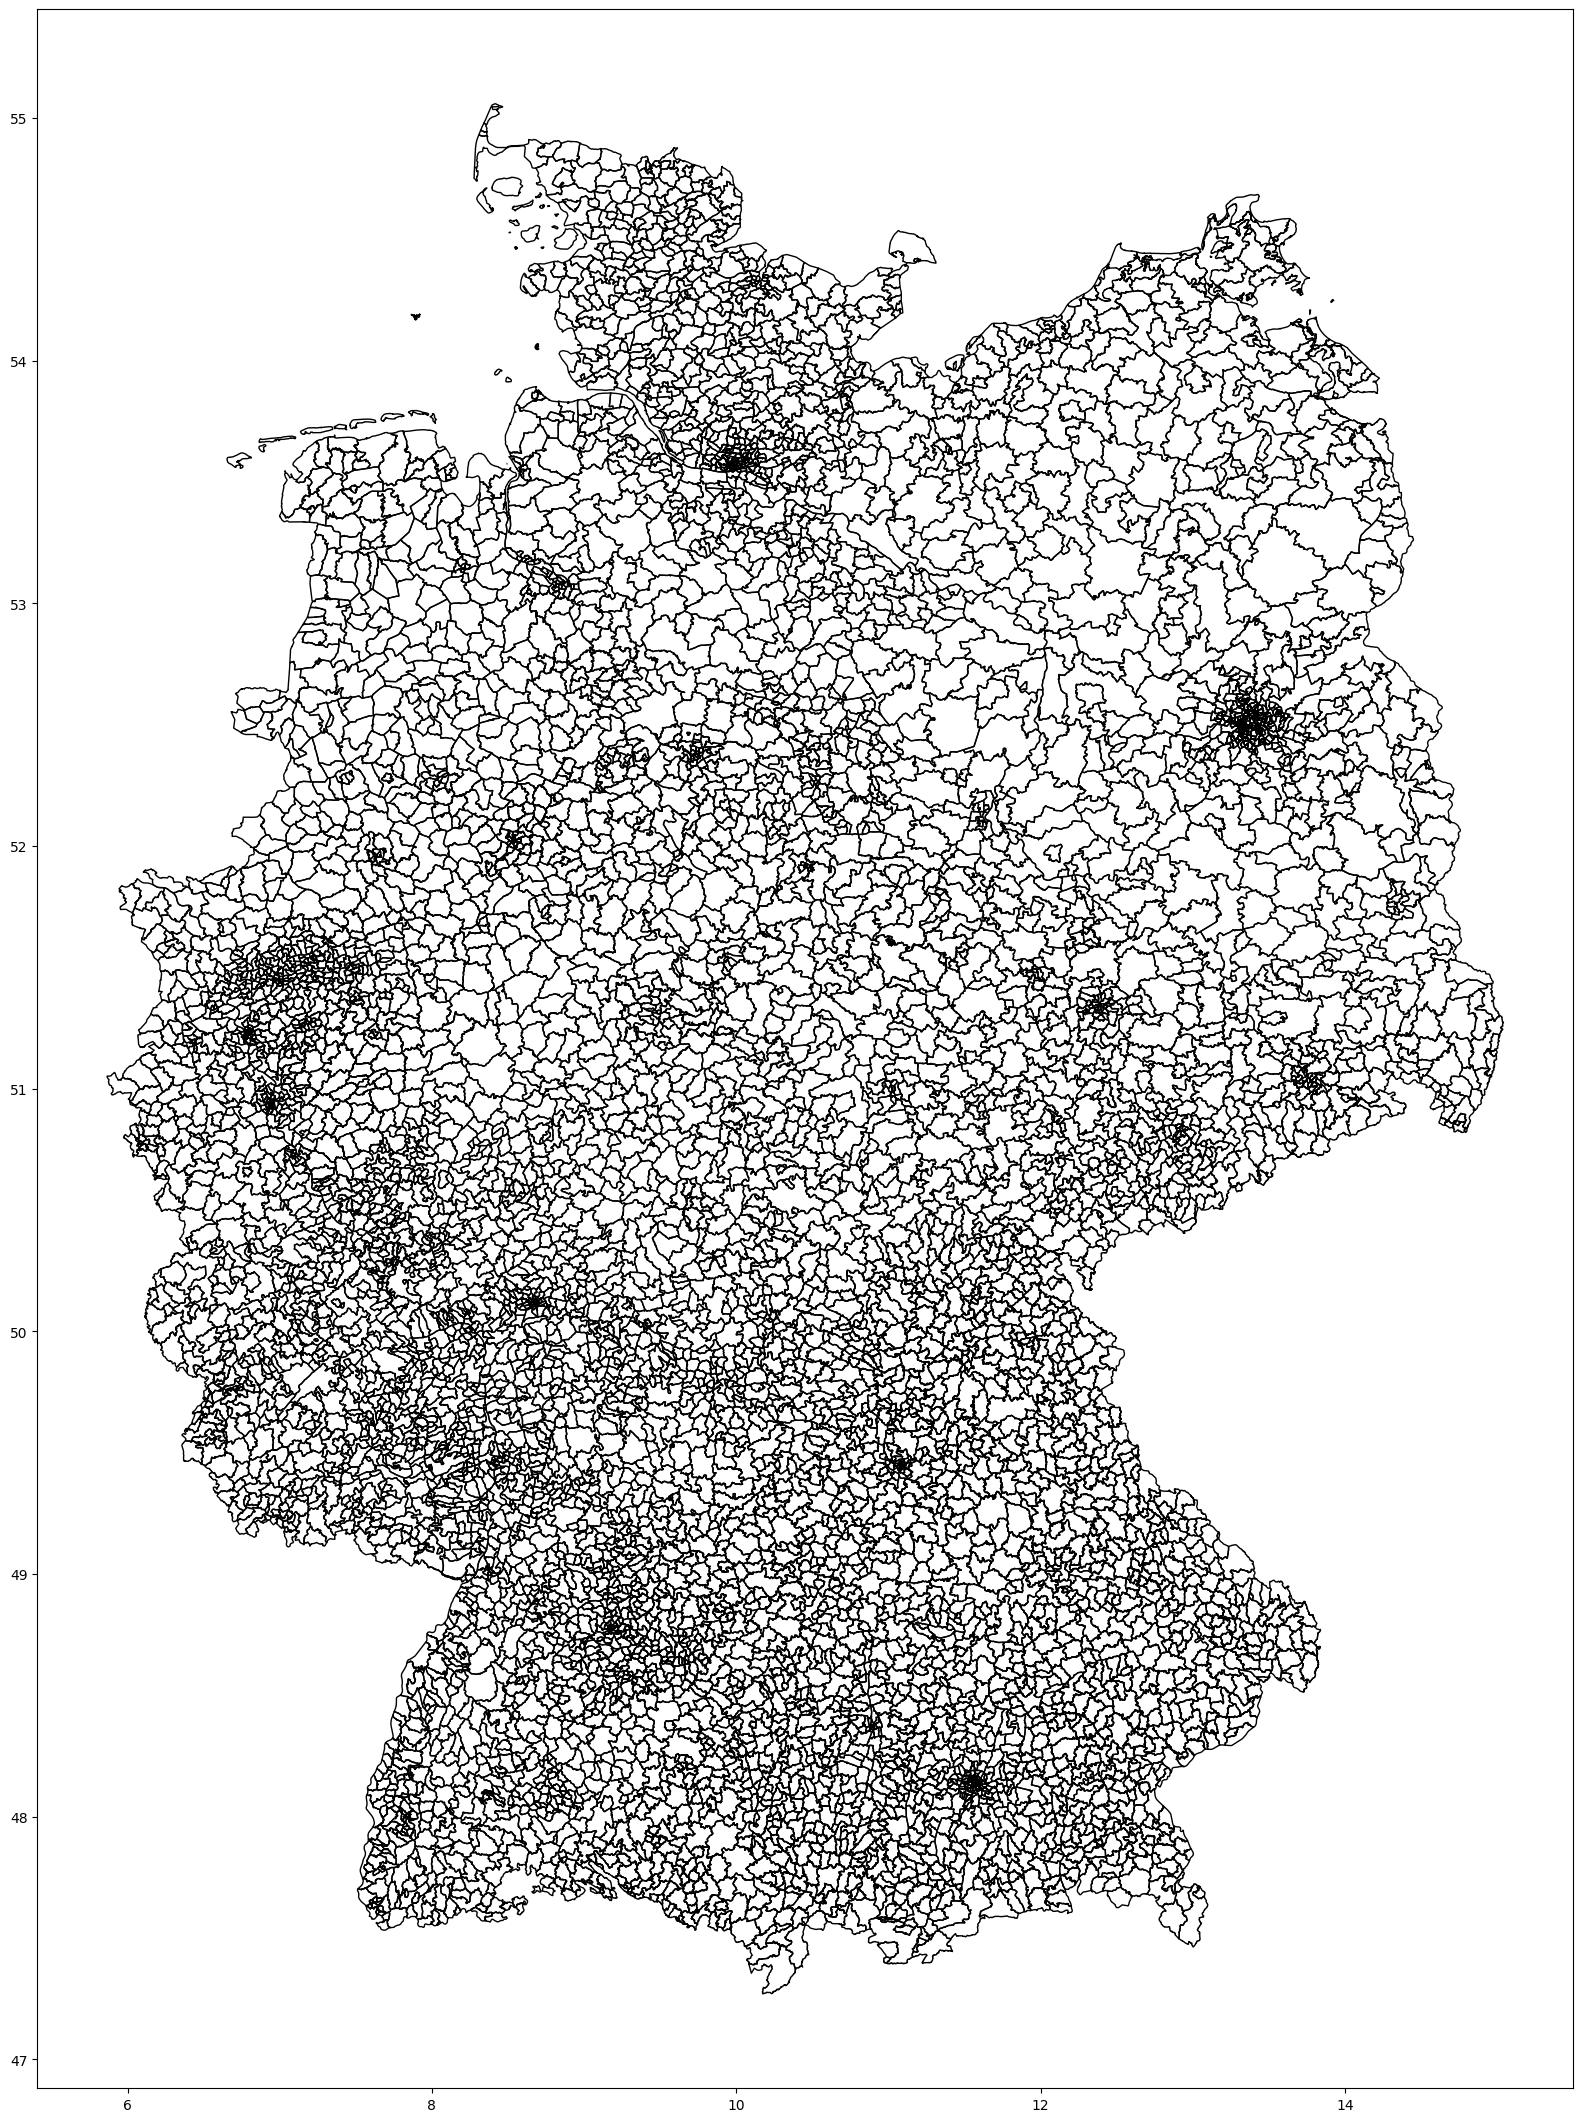

In [22]:
plz.plot(figsize=(21, 27), edgecolor="black", facecolor="none")